# Visit 2 – Machine Learning Pipeline

Addresses reviewer comments 30-37. Drops: record_id, injury_mechanism, buckets (+ other non-predictors). Y = buckets.

In [62]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    matthews_corrcoef, brier_score_loss
)
from sklearn.model_selection import train_test_split, ParameterSampler
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded.")


Libraries loaded.


In [63]:
df = pd.read_csv("visit2_3_27_26.csv")
print(df.shape)
df.head(3)


(217, 69)


,Treatment_present,prev_head_injury,import_phq9_score,import_gad7_score,high_total_sx_severity,cerv_flex,cerv_ext,l_lat_flex,r_lat_flex,subocc_flex,...,vmst_nausea_diff,voms_dizziness_diff,voms_headache_diff,voms_nausea_diff,vor_horiz_dizziness_diff,vor_horiz_fogginess_diff,vor_horiz_headache_diff,vor_vert_dizziness_diff,vor_vert_fogginess_diff,vor_vert_headache_diff
0,1,0,16.0,15.0,31.0,45.0,44.0,41.0,43.0,13.0,...,-1.0,2.0,-3.0,-1.0,2.0,1.0,-3.0,4.0,1.0,-3.0
1,1,0,1.0,0.0,0.0,54.0,54.0,45.0,49.0,12.0,...,0.0,0.0,0.0,0.0,-3.0,0.0,0.0,-2.0,0.0,0.0
2,1,1,14.0,9.0,88.0,62.0,45.0,36.0,37.0,7.0,...,-5.0,0.0,-1.0,-3.0,0.0,-5.0,-1.0,0.0,-5.0,-1.0


In [64]:
print(df["buckets"].value_counts())


buckets
1    176
0     41
Name: count, dtype: int64


In [65]:
# X: explicitly drop record_id, injury_mechanism, buckets, plus other non-predictor columns
cols_X = [
    "buckets", "record_id", "injury_mechanism",
    "days_2_clearance", "days_2_firstvisit",
    "high_total_sx_severity", "redcap_repeat_instance", "high_total_sx_severity_diff"
]
cols_X = [c for c in cols_X if c in df.columns]

X = df.drop(columns=cols_X)
y = df["buckets"]
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")


X shape: (217, 64)
y distribution:
buckets
1    176
0     41
Name: count, dtype: int64


## Comment 30 – EPV Reporting

In [66]:
n_total    = len(df)
n_minority = int(y.value_counts().min())
n_features = X.shape[1]
epv        = n_minority / n_features

print("=" * 50)
print(f"Total N           : {n_total}")
print(f"Minority class N  : {n_minority}")
print(f"Number of features: {n_features}")
print(f"EPV               : {epv:.2f}")
if epv < 10:
    print("WARNING: EPV < 10 – interpret results with caution (risk of overfitting).")
print("=" * 50)


Total N           : 217
Minority class N  : 41
Number of features: 64
EPV               : 0.64


## Shared Helper Functions (Comments 31, 32, 37)

In [67]:
def compute_metrics(y_true, y_pred, y_prob=None, B=1000, random_state=42):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pts = dict(
        accuracy     = accuracy_score(y_true, y_pred),
        bal_accuracy = balanced_accuracy_score(y_true, y_pred),
        precision    = precision_score(y_true, y_pred, zero_division=0),
        recall       = recall_score(y_true, y_pred, zero_division=0),
        f1           = f1_score(y_true, y_pred, zero_division=0),
        specificity  = specificity,
        mcc          = matthews_corrcoef(y_true, y_pred),
    )
    if y_prob is not None:
        pts["brier"] = brier_score_loss(y_true, y_prob)
    rng = np.random.default_rng(random_state)
    boot = {k: [] for k in pts}
    for _ in range(B):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, yp = y_true[idx], y_pred[idx]
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        spec_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else 0.0
        boot["accuracy"].append(accuracy_score(yt, yp))
        boot["bal_accuracy"].append(balanced_accuracy_score(yt, yp))
        boot["precision"].append(precision_score(yt, yp, zero_division=0))
        boot["recall"].append(recall_score(yt, yp, zero_division=0))
        boot["f1"].append(f1_score(yt, yp, zero_division=0))
        boot["specificity"].append(spec_b)
        boot["mcc"].append(matthews_corrcoef(yt, yp))
        if y_prob is not None:
            boot["brier"].append(brier_score_loss(yt, y_prob[idx]))
    cis = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boot.items()}
    print("Metric               Point Est   95% CI")
    print("-" * 48)
    for k, val in pts.items():
        lo, hi = cis[k]
        print(f"{k:<20} {val:.4f}      [{lo:.4f}, {hi:.4f}]")
    return pts, cis

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(fi_df, title="Top 20 Feature Importances"):
    top20 = fi_df.head(20).copy()
    plt.figure(figsize=(8, 6))
    plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return top20

def plot_effect_direction(model, X, top20, title="Average Effect"):
    top_feats = top20["feature"].tolist()
    effects = []
    for f in top_feats:
        med = X[f].median()
        X_hi = X[X[f] > med]
        X_lo = X[X[f] <= med]
        ph = model.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
        pl = model.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
        effects.append({"feature": f, "avg_effect": ph - pl})
    eff_df = pd.DataFrame(effects).sort_values("avg_effect", key=abs, ascending=False)
    colors = eff_df["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
    plt.figure(figsize=(8, 6))
    plt.barh(eff_df["feature"], eff_df["avg_effect"], color=colors)
    plt.xlabel("Avg Effect on P(prolonged recovery)")
    plt.axvline(0, color="black", lw=0.8)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    return eff_df

print("Helper functions ready.")


Helper functions ready.


In [68]:
n_neg = int((y == 0).sum())
n_pos = int((y == 1).sum())
scale_pos_weight_val = n_neg / n_pos
print(f"Negative: {n_neg}, Positive: {n_pos}, scale_pos_weight: {scale_pos_weight_val:.2f}")


Negative: 41, Positive: 176, scale_pos_weight: 0.23


## LightGBM

In [69]:
import lightgbm as lgb

X_lgbm = df.drop(columns=cols_X)
y_lgbm = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42)

param_dist = {
    "num_leaves":        [31, 50, 70],
    "max_depth":         [-1, 10, 20, 30],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "n_estimators":      [100, 200, 500, 1000],
    "min_child_samples": [10, 20, 30, 50],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
}
param_list = list(ParameterSampler(param_dist, n_iter=50, random_state=42))

best_score_lgbm, best_params_lgbm = 0, None
for params in param_list:
    m = lgb.LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1, **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_lgbm:
        best_score_lgbm = acc
        best_params_lgbm = params

print("Best params:", best_params_lgbm)
print(f"Best balanced accuracy (hold-out): {best_score_lgbm:.4f}")


Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 30, 'max_depth': 30, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best balanced accuracy (hold-out): 0.7917


In [70]:
y_true_lgbm, y_pred_lgbm, y_prob_lgbm = [], [], []
fi_sum_lgbm = np.zeros(X_lgbm.shape[1])

for i in range(len(df)):
    Xtr = X_lgbm.drop(index=i)
    ytr = y_lgbm.drop(index=i)
    Xte = X_lgbm.iloc[[i]]
    m = lgb.LGBMClassifier(random_state=42, class_weight="balanced",
                            verbose=-1, **best_params_lgbm)
    m.fit(Xtr, ytr)
    fi_sum_lgbm += m.booster_.feature_importance(importance_type="gain")
    y_pred_lgbm.append(m.predict(Xte)[0])
    y_prob_lgbm.append(m.predict_proba(Xte)[0, 1])
    y_true_lgbm.append(y_lgbm.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_lgbm = np.array(y_true_lgbm)
y_pred_lgbm = np.array(y_pred_lgbm)
y_prob_lgbm = np.array(y_prob_lgbm)
print("=== LightGBM LOOCV Results (Visit 2) ===")
metrics_lgbm, cis_lgbm = compute_metrics(y_true_lgbm, y_pred_lgbm, y_prob_lgbm)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== LightGBM LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7419      [0.6820, 0.7972]
bal_accuracy         0.6164      [0.5351, 0.6974]
precision            0.8571      [0.8000, 0.9042]
recall               0.8182      [0.7586, 0.8743]
f1                   0.8372      [0.7926, 0.8757]
specificity          0.4146      [0.2619, 0.5683]
mcc                  0.2180      [0.0637, 0.3649]
brier                0.1638      [0.1355, 0.1936]


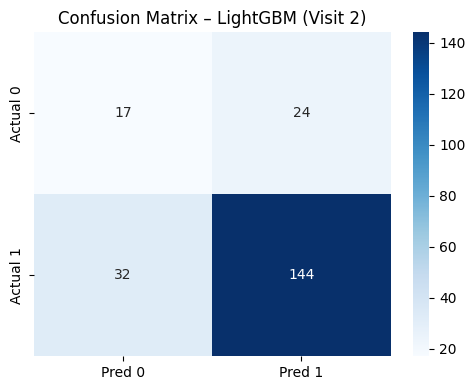

=== Top 20 Features – LightGBM ===
                 feature  importance
       Treatment_present  212.076787
       import_phq9_score  186.942883
       vor_vert_headache  151.888801
         l_cerv_rot_diff  130.973404
     vor_horiz_dizziness  122.075573
              r_cerv_rot  117.509657
              l_cerv_rot   90.182614
         subocc_ext_diff   85.056981
  import_gad7_score_diff   69.964724
         r_cerv_rot_diff   67.166608
                cerv_ext   60.643094
     vmst_dizziness_diff   58.490320
  import_phq9_score_diff   53.982719
         l_lat_flex_diff   47.601215
           cerv_ext_diff   47.224727
       import_gad7_score   45.286562
     bess_single_ec_diff   43.265481
          cerv_flex_diff   39.703984
  vor_vert_headache_diff   39.086168
vor_horiz_dizziness_diff   37.806445


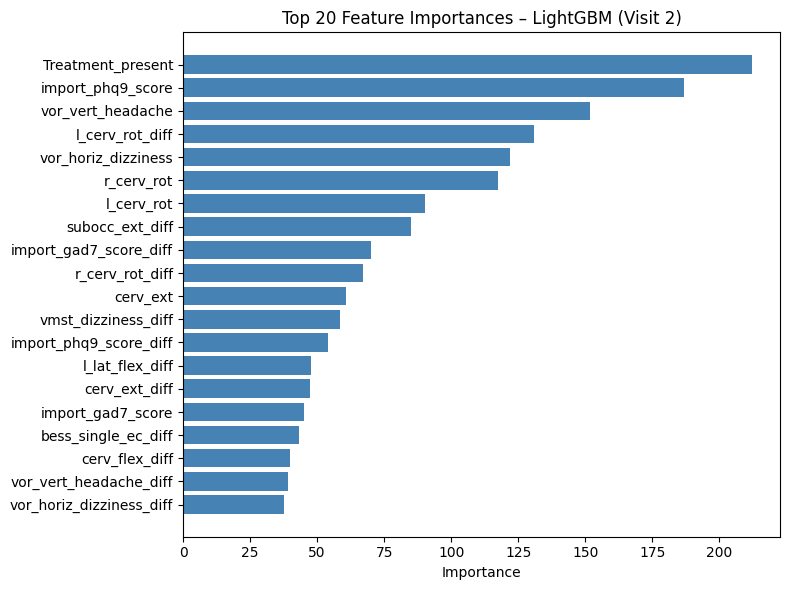

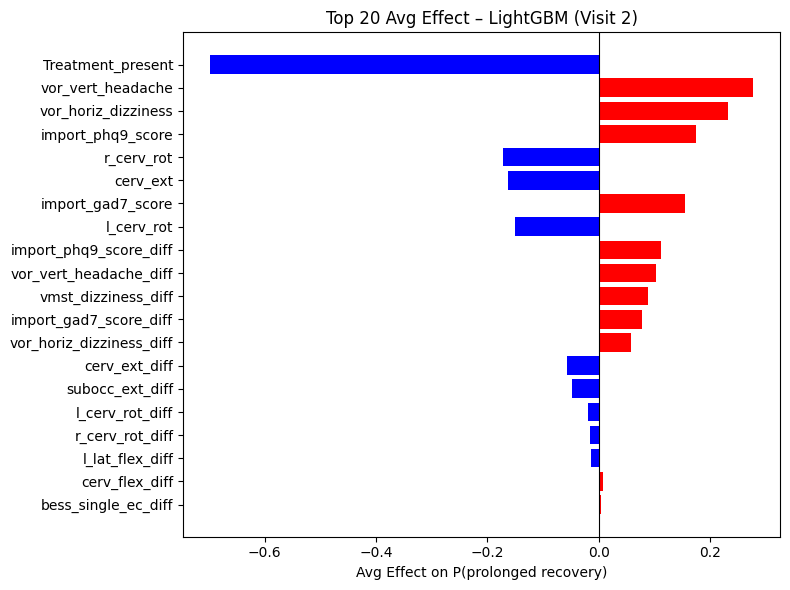

,feature,avg_effect
0,Treatment_present,-0.697582
2,vor_vert_headache,0.276869
4,vor_horiz_dizziness,0.231755
1,import_phq9_score,0.174914
5,r_cerv_rot,-0.171807
10,cerv_ext,-0.162946
15,import_gad7_score,0.155607
6,l_cerv_rot,-0.149882
12,import_phq9_score_diff,0.112167
18,vor_vert_headache_diff,0.102961


In [71]:
plot_confusion(y_true_lgbm, y_pred_lgbm, "Confusion Matrix – LightGBM (Visit 2)")
fi_df_lgbm = (pd.DataFrame({"feature": X_lgbm.columns, "importance": fi_sum_lgbm / len(df)})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – LightGBM ===")
print(fi_df_lgbm.head(20).to_string(index=False))
top20_lgbm = plot_feature_importance(fi_df_lgbm, "Top 20 Feature Importances – LightGBM (Visit 2)")
_m_lgbm = lgb.LGBMClassifier(random_state=42, class_weight="balanced",
                               verbose=-1, **best_params_lgbm).fit(X_lgbm, y_lgbm)
plot_effect_direction(_m_lgbm, X_lgbm, top20_lgbm, "Top 20 Avg Effect – LightGBM (Visit 2)")


## Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier

X_dt = df.drop(columns=cols_X)
y_dt = df["buckets"]

X_tr, X_te, y_tr, y_te = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)
param_dist_dt = {
    "criterion":        ["gini", "entropy", "log_loss"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
    "splitter":         ["best", "random"],
}
param_list_dt = list(ParameterSampler(param_dist_dt, n_iter=50, random_state=42))

best_score_dt, best_params_dt = 0, None
for params in param_list_dt:
    m = DecisionTreeClassifier(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_dt:
        best_score_dt = acc
        best_params_dt = params

print("Best params:", best_params_dt)
print(f"Best balanced accuracy: {best_score_dt:.4f}")


Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'gini'}
Best balanced accuracy: 0.8125


In [73]:
y_true_dt, y_pred_dt, y_prob_dt = [], [], []
fi_sum_dt = np.zeros(X_dt.shape[1])
for i in range(len(df)):
    Xtr = X_dt.drop(index=i)
    ytr = y_dt.drop(index=i)
    Xte = X_dt.iloc[[i]]
    m = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_params_dt)
    m.fit(Xtr, ytr)
    fi_sum_dt += m.feature_importances_
    y_pred_dt.append(m.predict(Xte)[0])
    y_prob_dt.append(m.predict_proba(Xte)[0, 1])
    y_true_dt.append(y_dt.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_dt, y_pred_dt, y_prob_dt = np.array(y_true_dt), np.array(y_pred_dt), np.array(y_prob_dt)
print("=== Decision Tree LOOCV Results (Visit 2) ===")
metrics_dt, cis_dt = compute_metrics(y_true_dt, y_pred_dt, y_prob_dt)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Decision Tree LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.6129      [0.5484, 0.6774]
bal_accuracy         0.5462      [0.4653, 0.6320]
precision            0.8333      [0.7708, 0.8912]
recall               0.6534      [0.5843, 0.7257]
f1                   0.7325      [0.6736, 0.7840]
specificity          0.4390      [0.2857, 0.6000]
mcc                  0.0752      [-0.0579, 0.2201]
brier                0.2901      [0.2401, 0.3410]


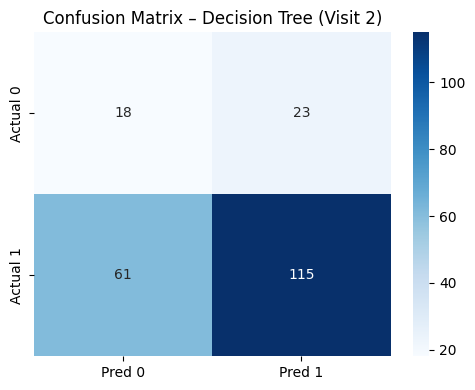

=== Top 20 Features – Decision Tree ===
                feature  importance
     vor_horiz_headache    0.189576
    vmst_dizziness_diff    0.092222
             l_lat_flex    0.083918
             subocc_ext    0.081520
    bess_single_ec_diff    0.054023
vor_vert_dizziness_diff    0.052413
         vmst_fogginess    0.049054
              cerv_flex    0.042769
        r_lat_flex_diff    0.041442
        r_cerv_rot_diff    0.039436
 import_gad7_score_diff    0.038907
             l_cerv_rot    0.035412
             r_cerv_rot    0.027485
     voms_headache_diff    0.024652
       npc_measure_diff    0.023394
          cerv_ext_diff    0.021182
       voms_nausea_diff    0.018622
         bess_tandem_ec    0.017509
        l_cerv_rot_diff    0.008935
 import_phq9_score_diff    0.008485


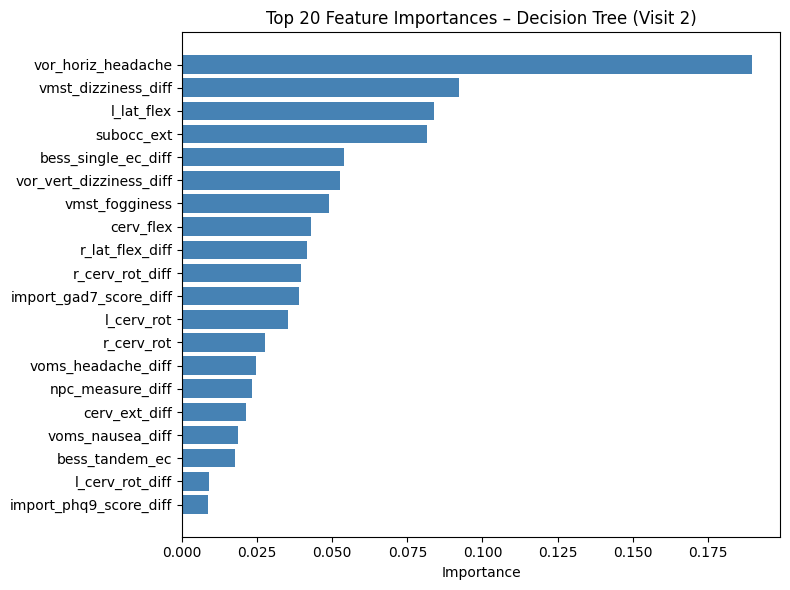

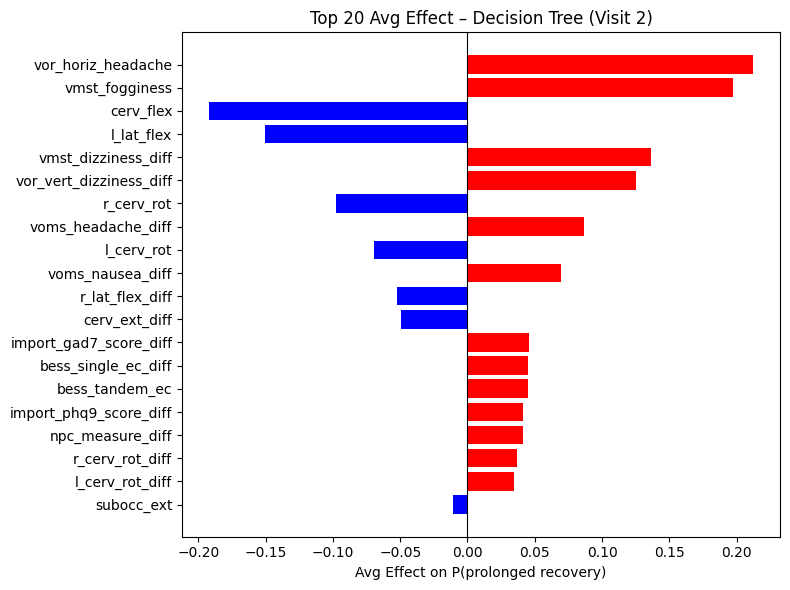

,feature,avg_effect
0,vor_horiz_headache,0.212106
6,vmst_fogginess,0.197086
7,cerv_flex,-0.191960
2,l_lat_flex,-0.150193
1,vmst_dizziness_diff,0.136218
5,vor_vert_dizziness_diff,0.125186
12,r_cerv_rot,-0.097549
13,voms_headache_diff,0.086540
11,l_cerv_rot,-0.069751
16,voms_nausea_diff,0.069739


In [74]:
plot_confusion(y_true_dt, y_pred_dt, "Confusion Matrix – Decision Tree (Visit 2)")
fi_df_dt = (pd.DataFrame({"feature": X_dt.columns, "importance": fi_sum_dt / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Decision Tree ===")
print(fi_df_dt.head(20).to_string(index=False))
top20_dt = plot_feature_importance(fi_df_dt, "Top 20 Feature Importances – Decision Tree (Visit 2)")
_m_dt = DecisionTreeClassifier(random_state=42, class_weight="balanced", **best_params_dt).fit(X_dt, y_dt)
plot_effect_direction(_m_dt, X_dt, top20_dt, "Top 20 Avg Effect – Decision Tree (Visit 2)")


## Random Forest

In [75]:
from sklearn.ensemble import RandomForestClassifier

X_rf = df.drop(columns=cols_X)
y_rf = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

param_dist_rf = {
    "criterion":        ["gini", "entropy"],
    "max_depth":        [None, 10, 20, 30, 50],
    "min_samples_split":[2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features":     [None, "sqrt", "log2"],
}
param_list_rf = list(ParameterSampler(param_dist_rf, n_iter=50, random_state=42))
best_score_rf, best_params_rf = 0, None
for params in param_list_rf:
    m = RandomForestClassifier(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_rf:
        best_score_rf = acc
        best_params_rf = params
print("Best params:", best_params_rf)
print(f"Best balanced accuracy: {best_score_rf:.4f}")


Best params: {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'gini'}
Best balanced accuracy: 0.7153


In [76]:
y_true_rf, y_pred_rf, y_prob_rf = [], [], []
fi_sum_rf = np.zeros(X_rf.shape[1])
for i in range(len(df)):
    Xtr = X_rf.drop(index=i)
    ytr = y_rf.drop(index=i)
    Xte = X_rf.iloc[[i]]
    m = RandomForestClassifier(random_state=42, class_weight="balanced", **best_params_rf)
    m.fit(Xtr, ytr)
    fi_sum_rf += m.feature_importances_
    y_pred_rf.append(m.predict(Xte)[0])
    y_prob_rf.append(m.predict_proba(Xte)[0, 1])
    y_true_rf.append(y_rf.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rf, y_pred_rf, y_prob_rf = np.array(y_true_rf), np.array(y_pred_rf), np.array(y_prob_rf)
print("=== Random Forest LOOCV Results (Visit 2) ===")
metrics_rf, cis_rf = compute_metrics(y_true_rf, y_pred_rf, y_prob_rf)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Random Forest LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7788      [0.7189, 0.8250]
bal_accuracy         0.5924      [0.5197, 0.6586]
precision            0.8441      [0.7864, 0.8895]
recall               0.8920      [0.8444, 0.9330]
f1                   0.8674      [0.8278, 0.9000]
specificity          0.2927      [0.1579, 0.4224]
mcc                  0.2067      [0.0476, 0.3561]
brier                0.1503      [0.1308, 0.1725]


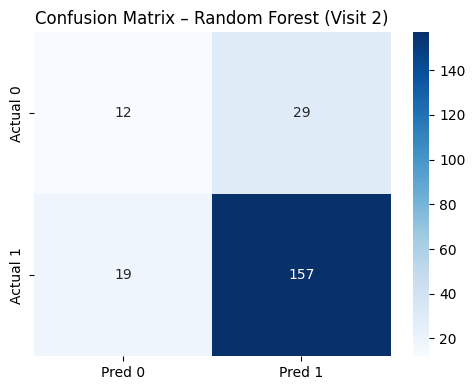

=== Top 20 Features – Random Forest ===
                feature  importance
      import_phq9_score    0.043934
      Treatment_present    0.039997
          cerv_ext_diff    0.034088
              cerv_flex    0.033393
             r_cerv_rot    0.033176
               cerv_ext    0.032397
        l_cerv_rot_diff    0.030644
        r_cerv_rot_diff    0.027801
      vor_vert_headache    0.027579
 import_phq9_score_diff    0.026306
             l_cerv_rot    0.025961
saccades_horiz_headache    0.025681
      import_gad7_score    0.025213
             l_lat_flex    0.024126
     vor_horiz_headache    0.024125
           npc_headache    0.020665
smoothpursuits_headache    0.019885
         cerv_flex_diff    0.018948
             r_lat_flex    0.018281
    vor_horiz_dizziness    0.018074


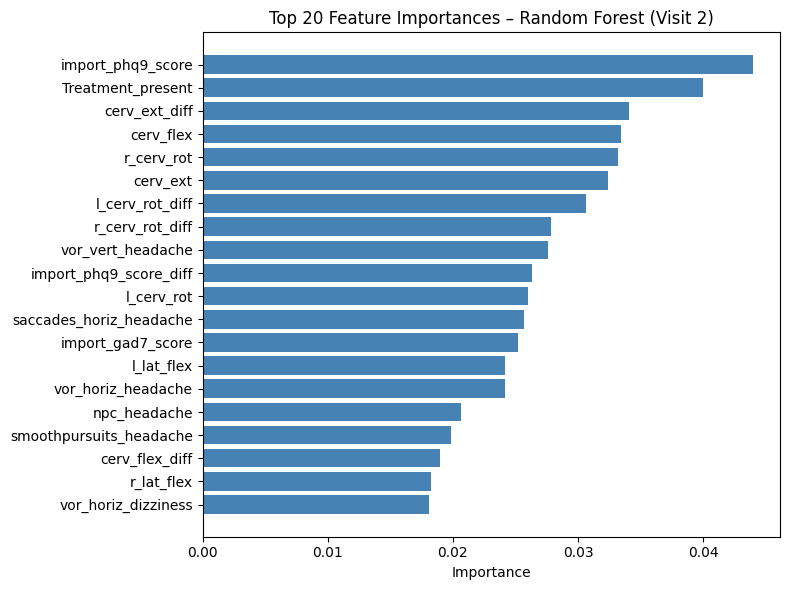

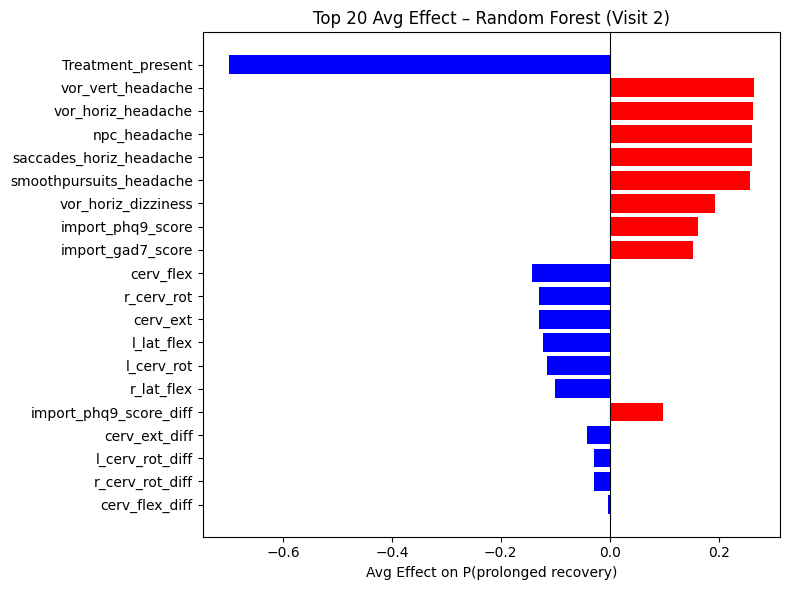

,feature,avg_effect
1,Treatment_present,-0.699124
8,vor_vert_headache,0.264332
14,vor_horiz_headache,0.262732
15,npc_headache,0.261280
11,saccades_horiz_headache,0.260478
16,smoothpursuits_headache,0.256566
19,vor_horiz_dizziness,0.192762
0,import_phq9_score,0.161218
12,import_gad7_score,0.153265
3,cerv_flex,-0.142686


In [77]:
plot_confusion(y_true_rf, y_pred_rf, "Confusion Matrix – Random Forest (Visit 2)")
fi_df_rf = (pd.DataFrame({"feature": X_rf.columns, "importance": fi_sum_rf / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Random Forest ===")
print(fi_df_rf.head(20).to_string(index=False))
top20_rf = plot_feature_importance(fi_df_rf, "Top 20 Feature Importances – Random Forest (Visit 2)")
_m_rf = RandomForestClassifier(random_state=42, class_weight="balanced", **best_params_rf).fit(X_rf, y_rf)
plot_effect_direction(_m_rf, X_rf, top20_rf, "Top 20 Avg Effect – Random Forest (Visit 2)")


## XGBoost

In [78]:
from xgboost import XGBClassifier

X_xgb = df.drop(columns=cols_X)
y_xgb = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

param_dist_xgb = {
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.2],
    "subsample":        [0.7, 0.85, 1.0],
    "n_estimators":     [50, 100, 150],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "gamma":            [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "reg_alpha":        [0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 1.5],
}
param_list_xgb = list(ParameterSampler(param_dist_xgb, n_iter=50, random_state=42))
best_score_xgb, best_params_xgb = 0, None
for params in param_list_xgb:
    m = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                      eval_metric="logloss", verbosity=0, **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_xgb:
        best_score_xgb = acc
        best_params_xgb = params
print("Best params:", best_params_xgb)
print(f"Best balanced accuracy: {best_score_xgb:.4f}")


Best params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best balanced accuracy: 0.8403


In [79]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])
for i in range(len(df)):
    Xtr = X_xgb.drop(index=i)
    ytr = y_xgb.drop(index=i)
    Xte = X_xgb.iloc[[i]]
    m = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                      eval_metric="logloss", verbosity=0, **best_params_xgb)
    m.fit(Xtr, ytr)
    fold_imp = m.get_booster().get_score(importance_type="gain")
    for feat, score in fold_imp.items():
        if feat in importance_accum_xgb.index:
            importance_accum_xgb.loc[feat, "importance"] += score
    y_pred_xgb.append(m.predict(Xte)[0])
    y_prob_xgb.append(m.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)
print("=== XGBoost LOOCV Results (Visit 2) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7143      [0.6544, 0.7742]
bal_accuracy         0.6087      [0.5336, 0.6938]
precision            0.8562      [0.8013, 0.9067]
recall               0.7784      [0.7184, 0.8400]
f1                   0.8155      [0.7692, 0.8588]
specificity          0.4390      [0.2894, 0.6000]
mcc                  0.1934      [0.0602, 0.3367]
brier                0.1713      [0.1432, 0.1995]


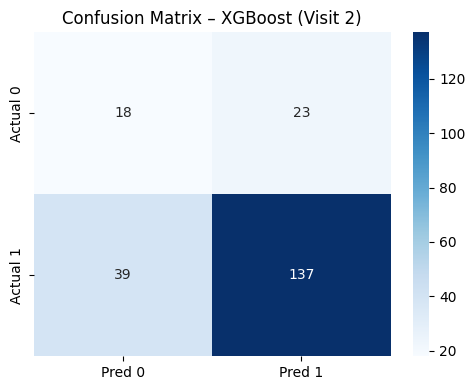

=== Top 20 Features – XGBoost ===
                      feature  importance
            Treatment_present         0.0
             prev_head_injury         0.0
          bess_tandem_ec_diff         0.0
                cerv_ext_diff         0.0
               cerv_flex_diff         0.0
       import_gad7_score_diff         0.0
       import_phq9_score_diff         0.0
              l_cerv_rot_diff         0.0
              l_lat_flex_diff         0.0
            npc_headache_diff         0.0
             npc_measure_diff         0.0
              r_cerv_rot_diff         0.0
              r_lat_flex_diff         0.0
saccades_horiz_fogginess_diff         0.0
 saccades_horiz_headache_diff         0.0
 saccades_vert_dizziness_diff         0.0
smoothpursuits_dizziness_diff         0.0
 smoothpursuits_headache_diff         0.0
              subocc_ext_diff         0.0
             subocc_flex_diff         0.0


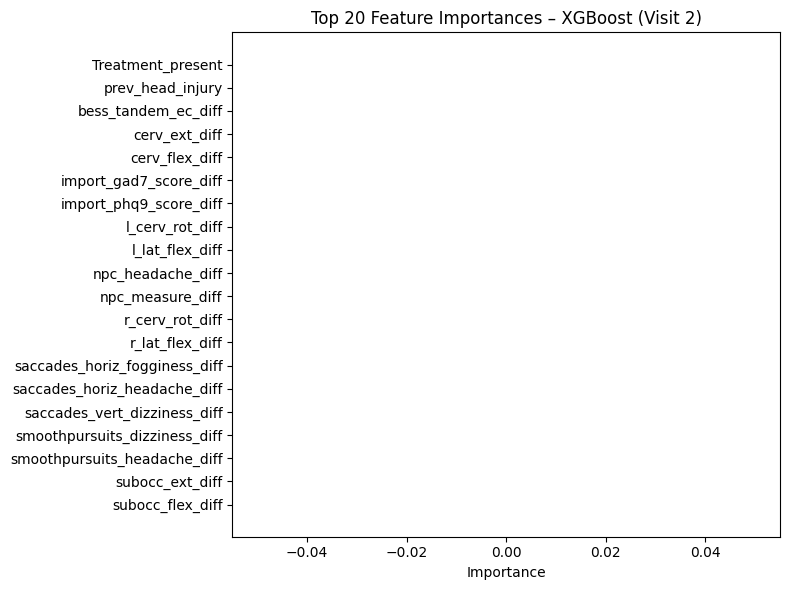

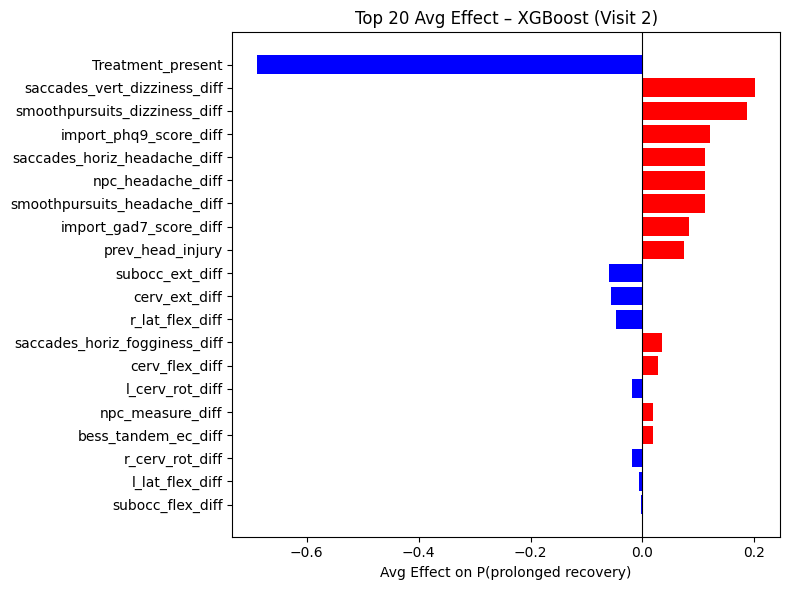

,feature,avg_effect
0,Treatment_present,-0.688539
15,saccades_vert_dizziness_diff,0.201309
16,smoothpursuits_dizziness_diff,0.186981
6,import_phq9_score_diff,0.120326
14,saccades_horiz_headache_diff,0.111898
9,npc_headache_diff,0.111225
17,smoothpursuits_headache_diff,0.110973
5,import_gad7_score_diff,0.083043
1,prev_head_injury,0.074250
18,subocc_ext_diff,-0.059971


In [80]:
plot_confusion(y_true_xgb, y_pred_xgb, "Confusion Matrix – XGBoost (Visit 2)")
importance_accum_xgb["importance"] /= len(df)
fi_df_xgb = (importance_accum_xgb.reset_index().rename(columns={"index": "feature"})
              .sort_values("importance", ascending=False))
print("=== Top 20 Features – XGBoost ===")
print(fi_df_xgb.head(20).to_string(index=False))
top20_xgb = plot_feature_importance(fi_df_xgb, "Top 20 Feature Importances – XGBoost (Visit 2)")
_m_xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val,
                        eval_metric="logloss", verbosity=0, **best_params_xgb).fit(X_xgb, y_xgb)
plot_effect_direction(_m_xgb, X_xgb, top20_xgb, "Top 20 Avg Effect – XGBoost (Visit 2)")


In [92]:
y_true_xgb, y_pred_xgb, y_prob_xgb = [], [], []
importance_accum_xgb = pd.DataFrame(0.0, index=X_xgb.columns, columns=["importance"])

# Specify importance_type in the constructor to ensure 'gain' is used
_xgb_model = XGBClassifier(
    random_state=42, 
    scale_pos_weight=scale_pos_weight_val,
    eval_metric="logloss", 
    verbosity=0, 
    importance_type="gain", # Explicitly set importance type
    **best_params_xgb
)

X_xgb = X_xgb.reset_index(drop=True)
y_xgb = y_xgb.reset_index(drop=True)

for i in range(len(df)):
    Xtr = X_xgb.drop(i)
    ytr = y_xgb.drop(i)
    Xte = X_xgb.iloc[[i]]

    _xgb_model.fit(Xtr, ytr)

    # FIX: Use feature_importances_ which aligns with X_xgb.columns
    importance_accum_xgb["importance"] += _xgb_model.feature_importances_

    y_pred_xgb.append(_xgb_model.predict(Xte)[0])
    y_prob_xgb.append(_xgb_model.predict_proba(Xte)[0, 1])
    y_true_xgb.append(y_xgb.iloc[i])

    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")

y_true_xgb, y_pred_xgb, y_prob_xgb = np.array(y_true_xgb), np.array(y_pred_xgb), np.array(y_prob_xgb)

# Calculate average importance and sort
importance_accum_xgb["importance"] /= len(df)
importance_table = importance_accum_xgb.sort_values(by="importance", ascending=False)

print("=== XGBoost LOOCV Results (Visit 1) ===")
metrics_xgb, cis_xgb = compute_metrics(y_true_xgb, y_pred_xgb, y_prob_xgb)

print("\n=== XGBoost Feature Importance (Average Gain) ===")
importance_table

Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== XGBoost LOOCV Results (Visit 1) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.7143      [0.6544, 0.7742]
bal_accuracy         0.6087      [0.5336, 0.6938]
precision            0.8562      [0.8013, 0.9067]
recall               0.7784      [0.7184, 0.8400]
f1                   0.8155      [0.7692, 0.8588]
specificity          0.4390      [0.2894, 0.6000]
mcc                  0.1934      [0.0602, 0.3367]
brier                0.1713      [0.1432, 0.1995]

=== XGBoost Feature Importance (Average Gain) ===
                               importance
vor_horiz_dizziness              0.102285
vor_vert_headache                0.070505
import_phq9_score                0.055086
Treatment_present                0.054459
import_phq9_score_diff           0.047528
...                                   ...
smoothpursuits_dizziness_diff    0.00

In [94]:
importance_table.head(20)

,importance
vor_horiz_dizziness,0.102285
vor_vert_headache,0.070505
import_phq9_score,0.055086
Treatment_present,0.054459
import_phq9_score_diff,0.047528
r_cerv_rot,0.041384
npc_headache_diff,0.037817
cerv_flex,0.037408
vmst_dizziness_diff,0.037163
l_cerv_rot,0.033974


## SVC

In [81]:
from sklearn.svm import SVC

X_svc = df.drop(columns=cols_X)
y_svc = df["buckets"]
X_tr, X_te, y_tr, y_te = train_test_split(X_svc, y_svc, test_size=0.2, random_state=42)

param_dist_svc = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  [1, 0.1, 0.01, 0.0001],
    "kernel": ["linear", "rbf", "poly"],
}
param_list_svc = list(ParameterSampler(param_dist_svc, n_iter=50, random_state=42))
best_score_svc, best_params_svc = 0, None
for params in param_list_svc:
    m = SVC(random_state=42, class_weight="balanced", **params)
    m.fit(X_tr, y_tr)
    acc = balanced_accuracy_score(y_te, m.predict(X_te))
    if acc > best_score_svc:
        best_score_svc = acc
        best_params_svc = params
print("Best params:", best_params_svc)
print(f"Best balanced accuracy: {best_score_svc:.4f}")


Best params: {'kernel': 'poly', 'gamma': 0.0001, 'C': 0.1}
Best balanced accuracy: 0.7500


In [82]:
y_true_svc, y_pred_svc, y_prob_svc = [], [], []
fi_sum_svc = np.zeros(X_svc.shape[1])
for i in range(len(df)):
    Xtr = X_svc.drop(index=i)
    ytr = y_svc.drop(index=i)
    Xte = X_svc.iloc[[i]]
    m = SVC(random_state=42, class_weight="balanced", probability=True, **best_params_svc)
    m.fit(Xtr, ytr)
    if best_params_svc.get("kernel") == "linear":
        fi_sum_svc += np.abs(m.coef_).flatten()
    y_pred_svc.append(m.predict(Xte)[0])
    y_prob_svc.append(m.predict_proba(Xte)[0, 1])
    y_true_svc.append(y_svc.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_svc, y_pred_svc, y_prob_svc = np.array(y_true_svc), np.array(y_pred_svc), np.array(y_prob_svc)
print("=== SVC LOOCV Results (Visit 2) ===")
metrics_svc, cis_svc = compute_metrics(y_true_svc, y_pred_svc, y_prob_svc)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== SVC LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.6313      [0.5622, 0.6959]
bal_accuracy         0.6885      [0.6066, 0.7622]
precision            0.9211      [0.8679, 0.9655]
recall               0.5966      [0.5198, 0.6667]
f1                   0.7241      [0.6594, 0.7782]
specificity          0.7805      [0.6486, 0.8975]
mcc                  0.2956      [0.1676, 0.4141]
brier                0.1466      [0.1187, 0.1772]


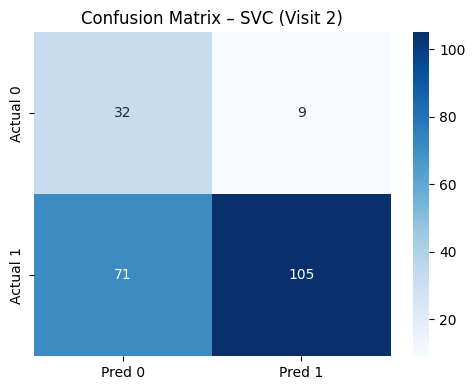

=== Top 20 Features – SVC ===
                      feature    importance
                    cerv_flex  3.369942e-02
      vor_vert_fogginess_diff  5.551115e-18
            Treatment_present  0.000000e+00
             subocc_flex_diff  0.000000e+00
          bess_single_ec_diff  0.000000e+00
          bess_tandem_ec_diff  0.000000e+00
                  voms_nausea  0.000000e+00
                  vmst_nausea  0.000000e+00
             prev_head_injury  0.000000e+00
                  subocc_flex  0.000000e+00
             voms_nausea_diff  0.000000e+00
          vmst_fogginess_diff -1.420455e-04
smoothpursuits_dizziness_diff -1.420455e-04
          voms_dizziness_diff -1.420455e-04
saccades_horiz_fogginess_diff -1.420455e-04
              r_cerv_rot_diff -2.840909e-04
              l_cerv_rot_diff -4.261364e-04
     vor_horiz_fogginess_diff -4.261364e-04
            npc_headache_diff -4.261364e-04
               bess_tandem_ec -4.261364e-04


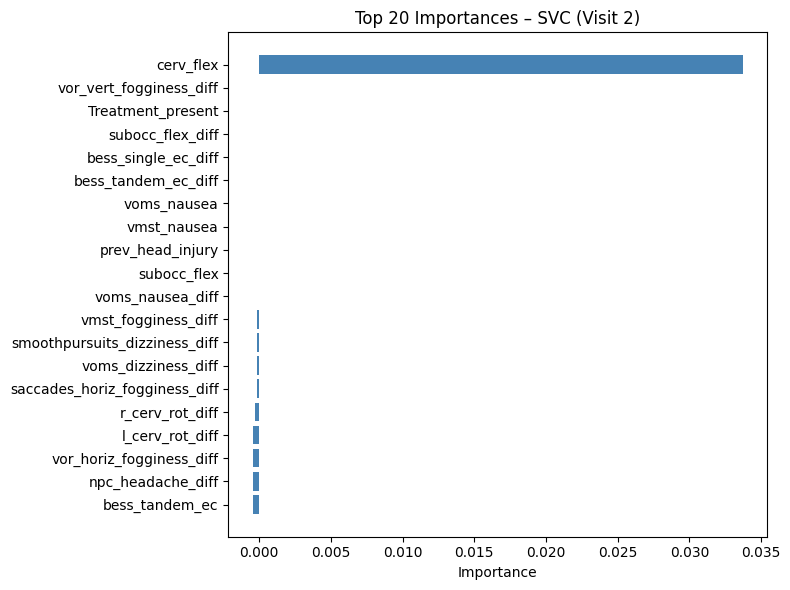

In [83]:
plot_confusion(y_true_svc, y_pred_svc, "Confusion Matrix – SVC (Visit 2)")
if best_params_svc.get("kernel") == "linear":
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": fi_sum_svc / len(df)})
                 .sort_values("importance", ascending=False))
else:
    from sklearn.inspection import permutation_importance as perm_imp
    _m_svc = SVC(random_state=42, class_weight="balanced", probability=True,
                 **best_params_svc).fit(X_svc, y_svc)
    perm = perm_imp(_m_svc, X_svc, y_svc, scoring="balanced_accuracy",
                    n_repeats=20, random_state=42, n_jobs=-1)
    fi_df_svc = (pd.DataFrame({"feature": X_svc.columns, "importance": perm.importances_mean})
                 .sort_values("importance", ascending=False))
print("=== Top 20 Features – SVC ===")
print(fi_df_svc.head(20).to_string(index=False))
top20_svc = plot_feature_importance(fi_df_svc, "Top 20 Importances – SVC (Visit 2)")


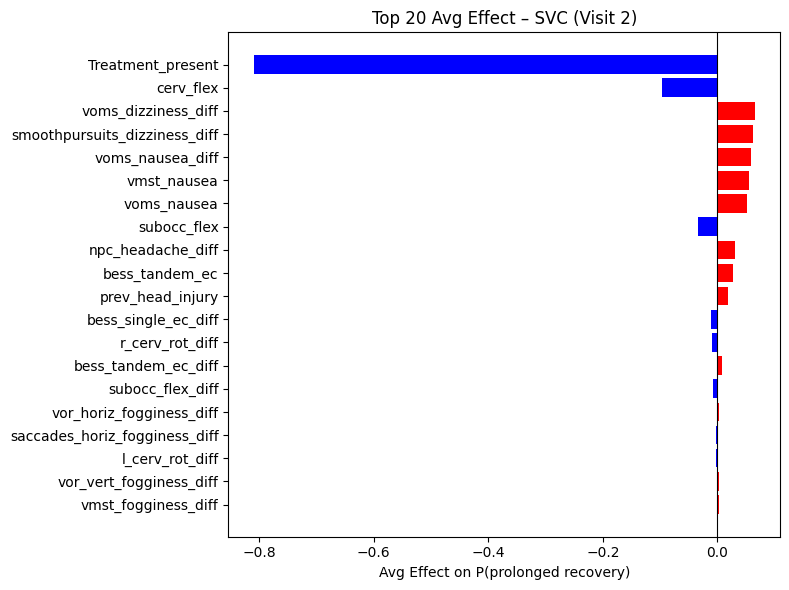

In [84]:
# Average effect plot – SVC
# Uses predict_proba (probability=True was set during LOOCV)
_m_svc = SVC(random_state=42, class_weight="balanced", probability=True,
             **best_params_svc).fit(X_svc, y_svc)

top_feats_svc = top20_svc["feature"].tolist()
effects_svc = []
for f in top_feats_svc:
    med = X_svc[f].median()
    X_hi = X_svc[X_svc[f] > med]
    X_lo = X_svc[X_svc[f] <= med]
    ph = _m_svc.predict_proba(X_hi)[:, 1].mean() if not X_hi.empty else 0.0
    pl = _m_svc.predict_proba(X_lo)[:, 1].mean() if not X_lo.empty else 0.0
    effects_svc.append({"feature": f, "avg_effect": ph - pl})

eff_svc = pd.DataFrame(effects_svc).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_svc["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_svc["feature"], eff_svc["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – SVC (Visit 2)")  # change to Visit 2 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Ridge Classifier

In [85]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

X_rg = df.drop(columns=cols_X)
y_rg = df["buckets"]

alphas = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20]
best_alpha_rg, best_score_rg = None, -np.inf
for alpha in alphas:
    m = RidgeClassifier(alpha=alpha, class_weight="balanced")
    scores = cross_val_score(m, X_rg, y_rg, cv=10, scoring="balanced_accuracy")
    if scores.mean() > best_score_rg:
        best_score_rg = scores.mean()
        best_alpha_rg = alpha
print(f"Best alpha: {best_alpha_rg}")
print(f"Best CV balanced accuracy: {best_score_rg:.4f}")


Best alpha: 5
Best CV balanced accuracy: 0.6030


In [86]:
y_true_rg, y_pred_rg, y_prob_rg = [], [], []
fi_sum_rg = np.zeros(X_rg.shape[1])
for i in range(len(df)):
    Xtr = X_rg.drop(index=i)
    ytr = y_rg.drop(index=i)
    Xte = X_rg.iloc[[i]]
    m = RidgeClassifier(alpha=best_alpha_rg, class_weight="balanced")
    m.fit(Xtr, ytr)
    fi_sum_rg += np.abs(m.coef_).flatten()
    pred = m.predict(Xte)[0]
    dec = m.decision_function(Xte)[0]
    prob = 1 / (1 + np.exp(-dec))
    y_pred_rg.append(pred)
    y_prob_rg.append(prob)
    y_true_rg.append(y_rg.iloc[i])
    if (i + 1) % 50 == 0 or (i + 1) == len(df):
        print(f"Progress: {i+1}/{len(df)}")
y_true_rg, y_pred_rg, y_prob_rg = np.array(y_true_rg), np.array(y_pred_rg), np.array(y_prob_rg)
print("=== Ridge Classifier LOOCV Results (Visit 2) ===")
metrics_rg, cis_rg = compute_metrics(y_true_rg, y_pred_rg, y_prob_rg)


Progress: 50/217
Progress: 100/217
Progress: 150/217
Progress: 200/217
Progress: 217/217
=== Ridge Classifier LOOCV Results (Visit 2) ===
Metric               Point Est   95% CI
------------------------------------------------
accuracy             0.6636      [0.6037, 0.7235]
bal_accuracy         0.6242      [0.5367, 0.7017]
precision            0.8705      [0.8088, 0.9209]
recall               0.6875      [0.6221, 0.7541]
f1                   0.7683      [0.7184, 0.8157]
specificity          0.5610      [0.4041, 0.7105]
mcc                  0.2027      [0.0595, 0.3388]
brier                0.2179      [0.1986, 0.2371]


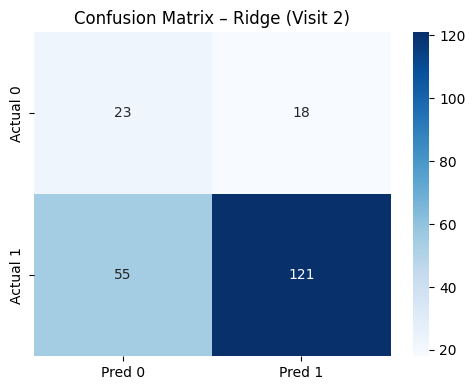

=== Top 20 Features – Ridge ===
                      feature  importance
            Treatment_present    0.484946
saccades_horiz_fogginess_diff    0.289127
          vor_horiz_dizziness    0.206511
                  vmst_nausea    0.157650
     smoothpursuits_dizziness    0.154805
            vor_vert_headache    0.154664
      vor_vert_dizziness_diff    0.140910
     vor_horiz_fogginess_diff    0.130524
                  voms_nausea    0.126208
 smoothpursuits_headache_diff    0.117548
          vmst_dizziness_diff    0.117449
               vmst_dizziness    0.115887
 saccades_horiz_headache_diff    0.108090
 saccades_vert_dizziness_diff    0.106884
      vor_vert_fogginess_diff    0.105454
           vor_vert_dizziness    0.100154
            npc_headache_diff    0.096878
smoothpursuits_dizziness_diff    0.079828
               bess_single_ec    0.071500
          bess_single_ec_diff    0.070764


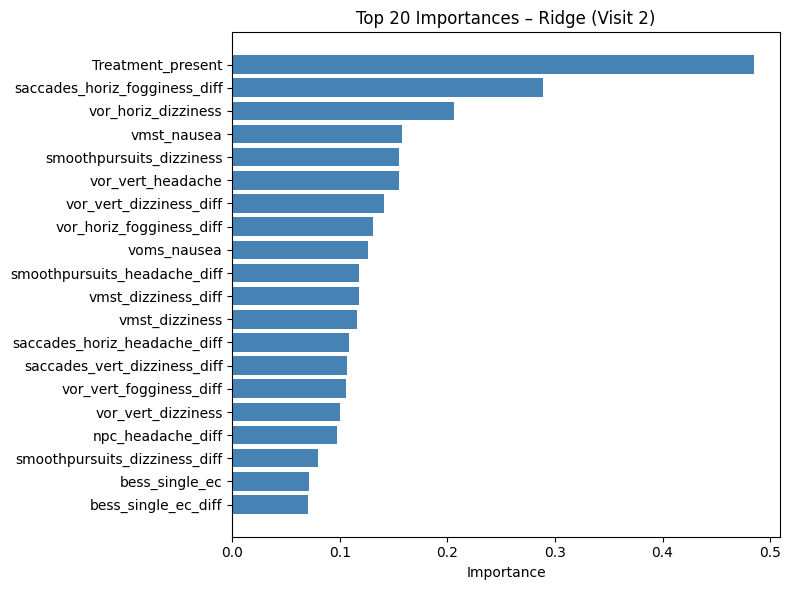

In [87]:
plot_confusion(y_true_rg, y_pred_rg, "Confusion Matrix – Ridge (Visit 2)")
fi_df_rg = (pd.DataFrame({"feature": X_rg.columns, "importance": fi_sum_rg / len(df)})
             .sort_values("importance", ascending=False))
print("=== Top 20 Features – Ridge ===")
print(fi_df_rg.head(20).to_string(index=False))
top20_rg = plot_feature_importance(fi_df_rg, "Top 20 Importances – Ridge (Visit 2)")


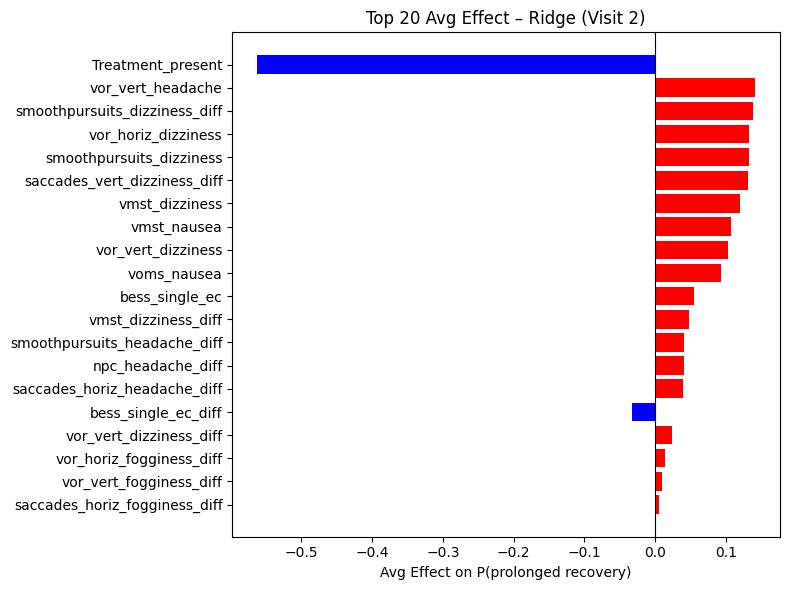

In [88]:
# Average effect plot – Ridge
# Uses sigmoid-transformed decision function as probability proxy
_m_rg = RidgeClassifier(alpha=best_alpha_rg, class_weight="balanced").fit(X_rg, y_rg)

top_feats_rg = top20_rg["feature"].tolist()
effects_rg = []
for f in top_feats_rg:
    med = X_rg[f].median()
    X_hi = X_rg[X_rg[f] > med]
    X_lo = X_rg[X_rg[f] <= med]

    def dec_to_prob(X_sub):
        if X_sub.empty:
            return 0.0
        dec = _m_rg.decision_function(X_sub)
        return (1 / (1 + np.exp(-dec))).mean()

    effects_rg.append({
        "feature": f,
        "avg_effect": dec_to_prob(X_hi) - dec_to_prob(X_lo)
    })

eff_rg = pd.DataFrame(effects_rg).sort_values("avg_effect", key=abs, ascending=False)
colors = eff_rg["avg_effect"].apply(lambda v: "red" if v > 0 else "blue")
plt.figure(figsize=(8, 6))
plt.barh(eff_rg["feature"], eff_rg["avg_effect"], color=colors)
plt.xlabel("Avg Effect on P(prolonged recovery)")
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 20 Avg Effect – Ridge (Visit 2)")  # change to Visit 2 as needed
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary Comparison Table – Visit 2 (Comment 37)

In [89]:
summary_rows = [
    ("LightGBM",       metrics_lgbm, cis_lgbm),
    ("Decision Tree",  metrics_dt,   cis_dt),
    ("Random Forest",  metrics_rf,   cis_rf),
    ("XGBoost",        metrics_xgb,  cis_xgb),
    ("SVC",            metrics_svc,  cis_svc),
    ("Ridge",          metrics_rg,   cis_rg),
]

rows = []
for name, pts, cis in summary_rows:
    row = {"Model": name}
    for k in ["accuracy", "bal_accuracy", "precision", "recall", "f1", "specificity", "mcc", "brier"]:
        if k in pts:
            lo, hi = cis[k]
            row[k] = f"{pts[k]:.3f} [{lo:.3f}, {hi:.3f}]"
        else:
            row[k] = "N/A"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")

# Use .style to create a readable, non-text based HTML table (best for Jupyter/Colab)
summary_df.style.set_caption("Visit 2 – Model Comparison (Point Estimate [95% Bootstrap CI])")

,accuracy,bal_accuracy,precision,recall,f1,specificity,mcc,brier
Model,,,,,,,,
LightGBM,"0.742 [0.682, 0.797]","0.616 [0.535, 0.697]","0.857 [0.800, 0.904]","0.818 [0.759, 0.874]","0.837 [0.793, 0.876]","0.415 [0.262, 0.568]","0.218 [0.064, 0.365]","0.164 [0.135, 0.194]"
Decision Tree,"0.613 [0.548, 0.677]","0.546 [0.465, 0.632]","0.833 [0.771, 0.891]","0.653 [0.584, 0.726]","0.732 [0.674, 0.784]","0.439 [0.286, 0.600]","0.075 [-0.058, 0.220]","0.290 [0.240, 0.341]"
Random Forest,"0.779 [0.719, 0.825]","0.592 [0.520, 0.659]","0.844 [0.786, 0.889]","0.892 [0.844, 0.933]","0.867 [0.828, 0.900]","0.293 [0.158, 0.422]","0.207 [0.048, 0.356]","0.150 [0.131, 0.172]"
XGBoost,"0.714 [0.654, 0.774]","0.609 [0.534, 0.694]","0.856 [0.801, 0.907]","0.778 [0.718, 0.840]","0.815 [0.769, 0.859]","0.439 [0.289, 0.600]","0.193 [0.060, 0.337]","0.171 [0.143, 0.199]"
SVC,"0.631 [0.562, 0.696]","0.689 [0.607, 0.762]","0.921 [0.868, 0.966]","0.597 [0.520, 0.667]","0.724 [0.659, 0.778]","0.780 [0.649, 0.897]","0.296 [0.168, 0.414]","0.147 [0.119, 0.177]"
Ridge,"0.664 [0.604, 0.724]","0.624 [0.537, 0.702]","0.871 [0.809, 0.921]","0.688 [0.622, 0.754]","0.768 [0.718, 0.816]","0.561 [0.404, 0.711]","0.203 [0.060, 0.339]","0.218 [0.199, 0.237]"
